In [ ]:

import pandas as pd
import numpy as np
from autofeat import AutoFeatClassifier
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer


# 学習用データの読み込み
train_data = pd.read_csv('../data/train.csv')
test_data = pd.read_csv('../data/test.csv')

# train_data = train_data.drop("Insulin", axis=1)
# test_data = test_data.drop("Insulin", axis=1)
train_data['BloodPressure'] = train_data['BloodPressure'].apply(lambda x: int(train_data['BloodPressure'].median()) if x == 0 else x)
train_data['BMI'] = train_data['BMI'].apply(lambda x: train_data['BMI'].median() if x <= 20 else x)
test_data['BloodPressure'] = test_data['BloodPressure'].apply(lambda x: int(test_data['BloodPressure'].median()) if x == 0 else x)
test_data['BMI'] = test_data['BMI'].apply(lambda x: test_data['BMI'].median() if x <= 20 else x)

# train_data['SkinThickness'] = train_data['SkinThickness'].replace(0, np.nan)
# train_data['Insulin'] = train_data['Insulin'].replace(0, np.nan)
# test_data['SkinThickness'] = test_data['SkinThickness'].replace(0, np.nan)
# test_data['Insulin'] = test_data['Insulin'].replace(0, np.nan)

# # KNN Imputer のインスタンス作成
# imputer = KNNImputer(
#     n_neighbors=5,         # 近傍の数（デフォルトは5）
#     weights='distance',     # 'uniform'（単純平均）または 'distance'（距離加重平均）
#     metric='nan_euclidean' # 欠損値を考慮したユークリッド距離
# )

# # 欠損値を補完
# train_data_imputed = imputer.fit_transform(train_data)
# test_data_imputed = imputer.fit_transform(test_data)

# # NumPy配列からDataFrameに戻す
# train_data = pd.DataFrame(train_data_imputed, columns=train_data.columns)
# test_data = pd.DataFrame(test_data_imputed, columns=test_data.columns)

datasets = [train_data, test_data]

# # 1. 列間の演算による特徴量
# for data in datasets:
#     data['BloodPressure_BMI_Ratio'] = data['BloodPressure'] / data['BMI']
#     data['Pregnancies_Age_Ratio'] = data['Pregnancies'] / data['Age']
#     data['BMI_Age_Product'] = data['BMI'] * data['Age']

# # 2. ビニング（離散化）による特徴量
# for data in datasets:
#     data['Age_Category'] = pd.cut(data['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle', 'Old'])
#     data['BMI_Category'] = pd.cut(data['BMI'], bins=[0, 18.5, 25, 30, float('inf')], labels=['Low', 'Normal', 'Overweight', 'Obese'])
#     data['Glucose_Level'] = pd.cut(data['Glucose'], bins=[0, 100, 125, float('inf')], labels=['Normal', 'Pre-Diabetes', 'Diabetes'])

# # 3. 医学的知識に基づく特徴量
for data in datasets:
#     data['Obesity_Flag'] = (data['BMI'] > 30).astype(int)
#     data['Hypertension_Flag'] = (data['BloodPressure'] > 140).astype(int)
    data['Glucose_Abnormal_Flag'] = (data['Glucose'] > 140).astype(int)

# # 4. 交互作用特徴量
# for data in datasets:
#     data['Glucose_BMI_Product'] = data['Glucose'] * data['BMI']
#     data['Pregnancies_DPF_Product'] = data['Pregnancies'] * data['DiabetesPedigreeFunction']
#     data['SkinThickness_Age_Ratio'] = data['SkinThickness'] / data['Age']

# # 5. 正規化やスケーリングを活用した特徴量
# for data in datasets:
#     data['Age_Adjusted_BMI'] = data['BMI'] / data['Age']
#     data['DPF_Normalized'] = data['DiabetesPedigreeFunction'] / data['DiabetesPedigreeFunction'].max()

# # 6. 非線形変換による特徴量
# for data in datasets:
#     data['Log_Glucose'] = np.log(data['Glucose'] + 1)  # +1で0を回避
#     data['BMI_Squared'] = data['BMI'] ** 2

# # 7. 複合リスクスコア
# for data in datasets:
#     data['Simple_Diabetes_Risk_Score'] = (
#         (data['Glucose'] > 140).astype(int) +
#         (data['BMI'] > 30).astype(int) +
#         (data['Age'] > 45).astype(int)
#     )

# # 8. 異常値フラグ
# for data in datasets:
#     data['High_SkinThickness_Flag'] = (data['SkinThickness'] > 50).astype(int)

# # 9. 年齢と他の変数の交互作用
# for data in datasets:
#     data['Age_BloodPressure_Product'] = data['Age'] * data['BloodPressure']

# # 10. 分布ベースの特徴量
# for data in datasets:
#     data['Glucose_Z_Score'] = (data['Glucose'] - data['Glucose'].mean()) / data['Glucose'].std()
#     data['BMI_Percentile_Rank'] = data['BMI'].rank() / len(data)

# # 11. 多項式特徴量
# for data in datasets:
#     data['Glucose_Cubed'] = data['Glucose'] ** 3

# # 12. 比率の拡張
# for data in datasets:
#     data['SkinThickness_BMI_Ratio'] = data['SkinThickness'] / data['BMI']
#     data['BloodPressure_Age_Ratio'] = data['BloodPressure'] / data['Age']

# # 13. カテゴリと数値の組み合わせ
# for data in datasets:
#     data['Age_Category_Glucose_Mean'] = data.groupby('Age_Category')['Glucose'].transform('mean')
#     data['Glucose_Age_Category_Diff'] = data['Glucose'] - data['Age_Category_Glucose_Mean']

# # 14. 医学的指標の近似
# for data in datasets:
#     data['BMI_Adjusted_BloodPressure'] = data['BloodPressure'] * (data['BMI'] / 25)

# # 15. 変数の組み合わせの拡張
# for data in datasets:
#     data['Pregnancies_BMI_Product'] = data['Pregnancies'] * data['BMI']
#     data['Glucose_DPF_Weighted'] = 0.7 * data['Glucose'] + 0.3 * data['DiabetesPedigreeFunction']

# # 16. 極端値の強調
# train_skin_thickness_99th = train_data['SkinThickness'].quantile(0.99)
# test_skin_thickness_99th = test_data['SkinThickness'].quantile(0.99)
# for data in datasets:
#     data['Very_Old_Flag'] = (data['Age'] > 60).astype(int)
#     data['Extreme_SkinThickness_Flag'] = (data['SkinThickness'] > (train_skin_thickness_99th if data is train_data else test_skin_thickness_99th)).astype(int)

# # 17. 距離ベースの特徴量
# for data in datasets:
#     data['Glucose_Distance_Normal'] = np.abs(data['Glucose'] - 100)
#     data['BMI_Distance_Standard'] = np.abs(data['BMI'] - 25)

# # 18. 条件付き特徴量
# for data in datasets:
#     data['Old_Obese_Flag'] = ((data['Age'] > 50) & (data['BMI'] > 30)).astype(int)
#     data['Young_Pregnant_Flag'] = ((data['Pregnancies'] > 0) & (data['Age'] < 30)).astype(int)

# # 19. クラスタリングを模倣した特徴量
# glucose_mean = train_data['Glucose'].mean()
# bmi_mean = train_data['BMI'].mean()
# for data in datasets:
#     data['Glucose_BMI_Distance'] = np.sqrt((data['Glucose'] - glucose_mean)**2 + (data['BMI'] - bmi_mean)**2)

# # 20. 合成変数の追加
# for data in datasets:
#     data['Physical_Stress_Score'] = (data['BloodPressure'] + data['SkinThickness']) / data['Age']

# # 21. 擬似動的特徴量
# for data in datasets:
#     data['Glucose_Age_Slope'] = data['Glucose'] / data['Age']
#     data['BMI_Per_Pregnancy'] = data['BMI'] / data['Pregnancies'].replace(0, np.nan)

# # 22. 外れ値ベースの特徴量（train_dataの統計量をtest_dataに適用）
# glucose_95th = train_data['Glucose'].quantile(0.95)
# for data in datasets:
#     data['High_Glucose_Flag'] = (data['Glucose'] > glucose_95th).astype(int)

# # 23. 変数のべき乗とルート
# for data in datasets:
#     data['Sqrt_Glucose'] = np.sqrt(data['Glucose'])

# # 24. 加重平均特徴量
# for data in datasets:
#     data['Age_Adjusted_Risk'] = (0.6 * data['BloodPressure'] + 0.4 * data['SkinThickness']) / data['Age']

# # 25. 条件付きカウント
# for data in datasets:
#     data['Risk_Factor_Count'] = (
#         (data['Glucose'] > 120).astype(int) +
#         (data['BMI'] > 28).astype(int)
#     )
#     data['Low_Value_Risk_Flag'] = (data['Glucose'] < 70).astype(int)

# # 26. 変数間の差分比率
# for data in datasets:
#     data['Glucose_BP_Diff_Ratio'] = (data['Glucose'] - data['BloodPressure']) / data['Glucose']
#     data['BMI_SkinThickness_Diff'] = data['BMI'] - data['SkinThickness']

# # 27. グループ内順位
# for data in datasets:
#     data['Glucose_Rank_In_Age_Category'] = data.groupby('Age_Category')['Glucose'].rank()

# # 28. 指数関数ベース
# for data in datasets:
#     data['Exp_Glucose'] = np.exp(data['Glucose'] / 100)
#     data['Inv_Exp_BMI'] = 1 / np.exp(data['BMI'] / 25)

# # 29. 複合比
# for data in datasets:
#     data['Glucose_BMI_Composite_Ratio'] = data['Glucose'] / (data['BMI'] + 1)

# # 30. 三角関数ベースの特徴量
# for data in datasets:
#     data['Sin_Glucose'] = np.sin(data['Glucose'] / 100)
#     data['Cos_BMI'] = np.cos(data['BMI'] / 25)

# # 31. 変数の変化率近似
# for data in datasets:
#     data['Glucose_Age_Change_Rate'] = (data['Glucose'] - 70) / data['Age']

# # 32. 統計的ロバスト特徴量
# glucose_median = train_data['Glucose'].median()
# bmi_trim_mean = train_data['BMI'].quantile([0.1, 0.9]).mean()
# for data in datasets:
#     data['Glucose_Median_Deviation'] = data['Glucose'] - glucose_median
#     data['BMI_Trim_Mean_Diff'] = data['BMI'] - bmi_trim_mean

# # 33. 複合フラグの拡張
# for data in datasets:
#     data['Low_Risk_Composite_Flag'] = ((data['Glucose'] < 100) & (data['BMI'] < 25)).astype(int)

# # 34. 対数スケールの比率
# for data in datasets:
#     data['Log_Glucose_BMI_Ratio'] = np.log(data['Glucose'] + 1) / np.log(data['BMI'] + 1)

# # 35. 変数の交互作用の拡張
# for data in datasets:
#     data['Glucose_Skin_Sqrt_Product'] = np.sqrt(data['Glucose'] * data['SkinThickness'])
#     data['BMI_BP_Weighted_Product'] = 0.4 * data['BMI'] * data['BloodPressure']

# # 36. パーセンタイルベースのフラグ
# glucose_90th = train_data['Glucose'].quantile(0.9)
# for data in datasets:
#     data['High_Glucose_90th_Flag'] = (data['Glucose'] > glucose_90th).astype(int)

train_data.head(15)

# x_column = 'Outcome'



,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_Abnormal_Flag
0,200,9,125,74,0,0,28.536910,0.444902,45,1,0
1,3832,4,109,80,0,0,28.047673,0.238243,22,0,0
2,4927,4,88,78,39,0,52.371341,0.279471,26,0,0
3,4088,9,125,74,0,0,40.062688,0.203922,45,0,0
4,3644,5,107,78,44,284,52.935068,0.284959,45,1,0
5,3323,5,84,64,0,0,33.459536,0.505127,26,0,0
6,2203,2,138,86,30,0,32.804714,0.269270,27,1,0
7,565,1,123,52,0,0,39.865034,0.714738,45,1,0
8,1386,1,138,76,30,0,39.660380,0.503107,23,0,0
9,4162,7,100,74,0,0,33.396364,0.238128,43,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler





# # 標準化
# scaler = StandardScaler()
# standardized_train_data = scaler.fit_transform(train_data[numeric_columns])
# standardized_test_data = scaler.fit_transform(test_data[numeric_columns])

# # 結果をデータフレームに戻す
# train_data[numeric_columns] = standardized_train_data
# test_data[numeric_columns] = standardized_test_data

# # 結果の表示
# print("\n補完後のデータ:")
# print(train_data.head(15))
# print(test_data.head(15))

# # 散布図の作成
# x_column = 'Outcome'
# for column in train_data.columns:
#     if column != x_column and column != 'index':
#         plt.figure(figsize=(10, 6))
#         plt.scatter(train_data[x_column], train_data[column], label=column)
#         plt.xlabel(x_column)
#         plt.ylabel(column)
#         plt.title(f'Scatter Plot: {x_column} vs {column}')
#         plt.legend()
#         plt.grid(True, alpha=0.3)
#         plt.show()

# # ヒストグラムの作成
# for column in train_data.columns:
#   if column != x_column and column != 'index':
#     plt.figure(figsize=(10, 6))  # 新しい図を作成
#     plt.hist(train_data[column], bins=50)
#     plt.title(f'Histogram of {column}')
#     plt.xlabel('Value')
#     plt.ylabel('Frequency')
#     plt.show()



In [ ]:
numeric_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                   'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

numeric_train_data = train_data[numeric_columns]
numeric_test_data = test_data[numeric_columns]

# AutoFeat
X_train = train_data[numeric_columns]
y_train = train_data['Outcome']
X_test = test_data[numeric_columns]

af_classifier = AutoFeatClassifier(
    verbose=1,
    feateng_steps=2,
    )

numeric_train_data_transformed = af_classifier.fit_transform(X_train, y_train)
numeric_test_data_transformed = af_classifier.transform(X_test)

numeric_train_data_transformed_df = pd.DataFrame(numeric_train_data_transformed)
numeric_test_data_transformed_df = pd.DataFrame(numeric_test_data_transformed)

train_data = pd.concat([train_data.reset_index(drop=True), numeric_train_data_transformed_df], axis=1)
test_data = pd.concat([test_data.reset_index(drop=True), numeric_test_data_transformed_df], axis=1)

print(train_data)
print(test_data)

train_data.to_csv('../data/train_特徴量増加.csv')
test_data.to_csv('../data/test_特徴量増加.csv')


[featsel] Scaling data...done.
      index  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  \
0       200            9      125             74              0        0   
1      3832            4      109             80              0        0   
2      4927            4       88             78             39        0   
3      4088            9      125             74              0        0   
4      3644            5      107             78             44      284   
...     ...          ...      ...            ...            ...      ...   
2856   4859            6      126             88             41        0   
2857   4931            4       88             74             17        0   
2858   3264            0      144             88              0        0   
2859   2607            2      113             74              0        0   
2860   2732            2      108             80              0        0   

            BMI  DiabetesPedigreeFunction  Age  Outcome 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency

# 学習用データの読み込み
train_data = pd.read_csv('../data/train_特徴量増加.csv')
train_data = train_data.drop(columns=train_data.columns[0])
train_data = train_data.drop("Pregnancies.1", axis=1)
train_data = train_data.drop("Glucose.1", axis=1)
train_data = train_data.drop("BloodPressure.1", axis=1)
train_data = train_data.drop("SkinThickness.1", axis=1)
train_data = train_data.drop("BMI.1", axis=1)
train_data = train_data.drop("DiabetesPedigreeFunction.1", axis=1)
train_data = train_data.drop("Age.1", axis=1)
train_data = train_data.drop("Insulin.1", axis=1)
# train_data = train_data.drop("BMI**3", axis=1)
# train_data = train_data.drop("Abs(Age)/Age", axis=1)


test_data = pd.read_csv('../data/test_特徴量増加.csv')
test_data = test_data.drop(columns=test_data.columns[0])
test_data = test_data.drop("Pregnancies.1", axis=1)
test_data = test_data.drop("Glucose.1", axis=1)
test_data = test_data.drop("BloodPressure.1", axis=1)
test_data = test_data.drop("SkinThickness.1", axis=1)
test_data = test_data.drop("BMI.1", axis=1)
test_data = test_data.drop("DiabetesPedigreeFunction.1", axis=1)
test_data = test_data.drop("Age.1", axis=1)
test_data = test_data.drop("Insulin.1", axis=1)
# test_data = test_data.drop("BMI**3", axis=1)
# test_data = test_data.drop("Abs(Age)/Age", axis=1)



# def feature_selection(train_data, test_data, target_col='Outcome',
#                      corr_threshold=0.08, feature_corr_threshold=0.85,
#                      categorical_cols=None):

#     # 元の'index'列を保持
#     original_train_index = train_data['index']
#     original_test_index = test_data['index']

#     # 'index'列をインデックスとして設定
#     train_data = train_data.set_index('index')
#     test_data = test_data.set_index('index')

#     # 元のindexを保持（処理用）
#     train_index = train_data.index
#     test_index = test_data.index

#     # 訓練データの特徴量と目的変数を分離
#     X_train = train_data.drop(columns=[target_col])
#     y_train = train_data[target_col]

#     # カテゴリ変数と数値変数を分離
#     if categorical_cols is None:
#         # カテゴリ変数を自動検出（object型またはcategory型）
#         categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
#     numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

#     # 1. 目的変数との相関分析
#     selected_features = []

#     # 数値特徴量の相関分析（ピアソンの相関係数）
#     if numeric_cols:
#         X_train_numeric = X_train[numeric_cols]
#         correlations = X_train_numeric.corrwith(y_train).abs()
#         numeric_selected = correlations[correlations >= corr_threshold].index.tolist()
#         selected_features.extend(numeric_selected)

#     # カテゴリ特徴量の相関分析（クラメールのV）
#     if categorical_cols:
#         for col in categorical_cols:
#             # 分割表を作成
#             contingency_table = pd.crosstab(X_train[col], y_train)
#             chi2, _, _, _ = chi2_contingency(contingency_table)
#             n = contingency_table.sum().sum()
#             min_dim = min(contingency_table.shape) - 1
#             cramer_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

#             if cramer_v >= corr_threshold:
#                 selected_features.append(col)

#     print(f"Initial selected features (after target correlation): {len(selected_features)} features")

#     # 選択された特徴量でデータフレームを更新
#     X_train_selected = X_train[selected_features]

#     # 2. 特徴量間の相関分析
#     features_to_remove = set()

#     # 数値特徴量間の相関（ピアソンの相関係数）
#     numeric_selected = [f for f in selected_features if f in numeric_cols]
#     if len(numeric_selected) > 1:
#         corr_matrix = X_train_selected[numeric_selected].corr().abs()
#         variances = X_train_selected[numeric_selected].var()

#         for i in range(len(corr_matrix.columns)):
#             for j in range(i + 1, len(corr_matrix.columns)):
#                 if corr_matrix.iloc[i, j] >= feature_corr_threshold:
#                     feat1 = corr_matrix.columns[i]
#                     feat2 = corr_matrix.columns[j]
#                     if feat1 not in features_to_remove and feat2 not in features_to_remove:
#                         if variances[feat1] < variances[feat2]:
#                             features_to_remove.add(feat1)
#                         else:
#                             features_to_remove.add(feat2)

#     # カテゴリ特徴量間の相関（クラメールのV）
#     cat_selected = [f for f in selected_features if f in categorical_cols]
#     if len(cat_selected) > 1:
#         for i in range(len(cat_selected)):
#             for j in range(i + 1, len(cat_selected)):
#                 feat1, feat2 = cat_selected[i], cat_selected[j]
#                 contingency_table = pd.crosstab(X_train_selected[feat1], X_train_selected[feat2])
#                 chi2, _, _, _ = chi2_contingency(contingency_table)
#                 n = contingency_table.sum().sum()
#                 min_dim = min(contingency_table.shape) - 1
#                 cramer_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

#                 if cramer_v >= feature_corr_threshold:
#                     # カテゴリ変数の場合、ユニーク値の少ない方を削除
#                     if feat1 not in features_to_remove and feat2 not in features_to_remove:
#                         if X_train_selected[feat1].nunique() < X_train_selected[feat2].nunique():
#                             features_to_remove.add(feat1)
#                         else:
#                             features_to_remove.add(feat2)

#     # 最終的な特徴量リストを作成
#     final_features = [feat for feat in selected_features if feat not in features_to_remove]
#     print(f"Final selected features (after feature correlation): {len(final_features)} features")
#     print(f"Removed features: {list(features_to_remove)}")

#     # 選択された特徴量で訓練データとテストデータを更新
#     selected_train = pd.DataFrame(X_train[final_features], index=train_index)
#     selected_train[target_col] = y_train
#     selected_test = pd.DataFrame(test_data[final_features], index=test_index)

#     # インデックスをリセットして元の'index'を列として復元
#     selected_train = selected_train.reset_index(drop=True)
#     selected_train.insert(0, 'index', original_train_index.values)
#     selected_test = selected_test.reset_index(drop=True)
#     selected_test.insert(0, 'index', original_test_index.values)

#     return selected_train, selected_test, final_features

# # 特徴量選択の実行（categorical_colsを指定するか、自動検出に任せる）
# selected_train, selected_test, selected_features = feature_selection(
#     train_data,
#     test_data,
#     target_col='Outcome',
#     corr_threshold=0.09,
#     feature_corr_threshold=0.8,
#     categorical_cols=None  # 必要に応じてカテゴリ列のリストを指定
# )

# # 結果の確認
# print("\nSelected features:", selected_features)
# print("\nSelected train data shape:", selected_train.shape)
# print("Selected test data shape:", selected_test.shape)


In [5]:
# selected_train.to_csv('../data/train_特徴量選択.csv')
# selected_test.to_csv('../data/test_特徴量選択.csv')
train_data.to_csv('../data/train_特徴量選択.csv')
test_data.to_csv('../data/test_特徴量選択.csv')

<Axes: >

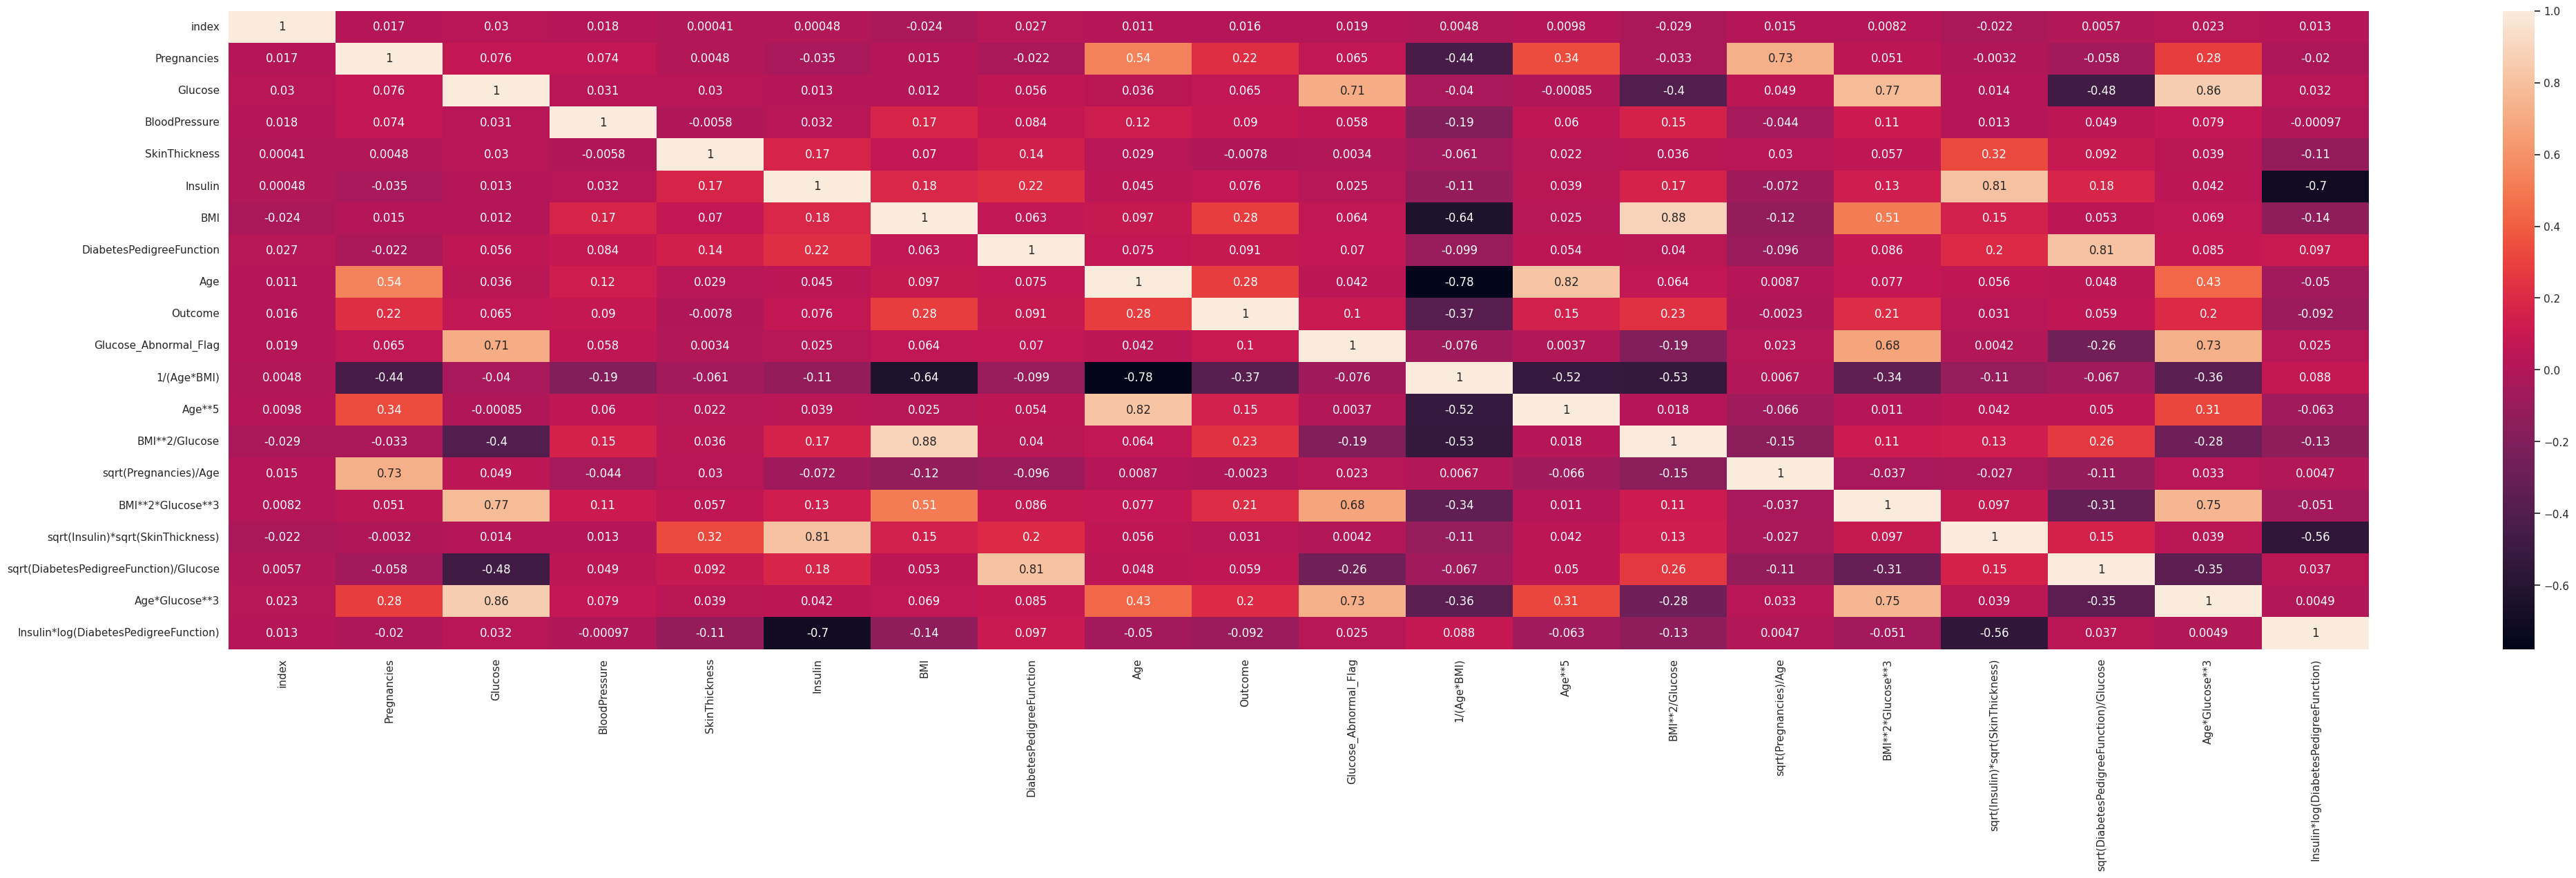

In [6]:
import seaborn as sns

# sns.set(style='darkgrid')
# plt.figure(figsize=(50,12))
# sns.heatmap(selected_train.corr(), annot=True)

sns.set(style='darkgrid')
plt.figure(figsize=(50,12))
sns.heatmap(train_data.corr(), annot=True)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2861 entries, 0 to 2860
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   index                              2861 non-null   int64  
 1   Pregnancies                        2861 non-null   int64  
 2   Glucose                            2861 non-null   int64  
 3   BloodPressure                      2861 non-null   int64  
 4   SkinThickness                      2861 non-null   int64  
 5   BMI                                2861 non-null   float64
 6   DiabetesPedigreeFunction           2861 non-null   float64
 7   Age                                2861 non-null   int64  
 8   Outcome                            2861 non-null   int64  
 9   Glucose_Abnormal_Flag              2861 non-null   int64  
 10  1/(Age*BMI)                        2861 non-null   float64
 11  sqrt(Insulin)*sqrt(SkinThickness)  2861 non-null   float

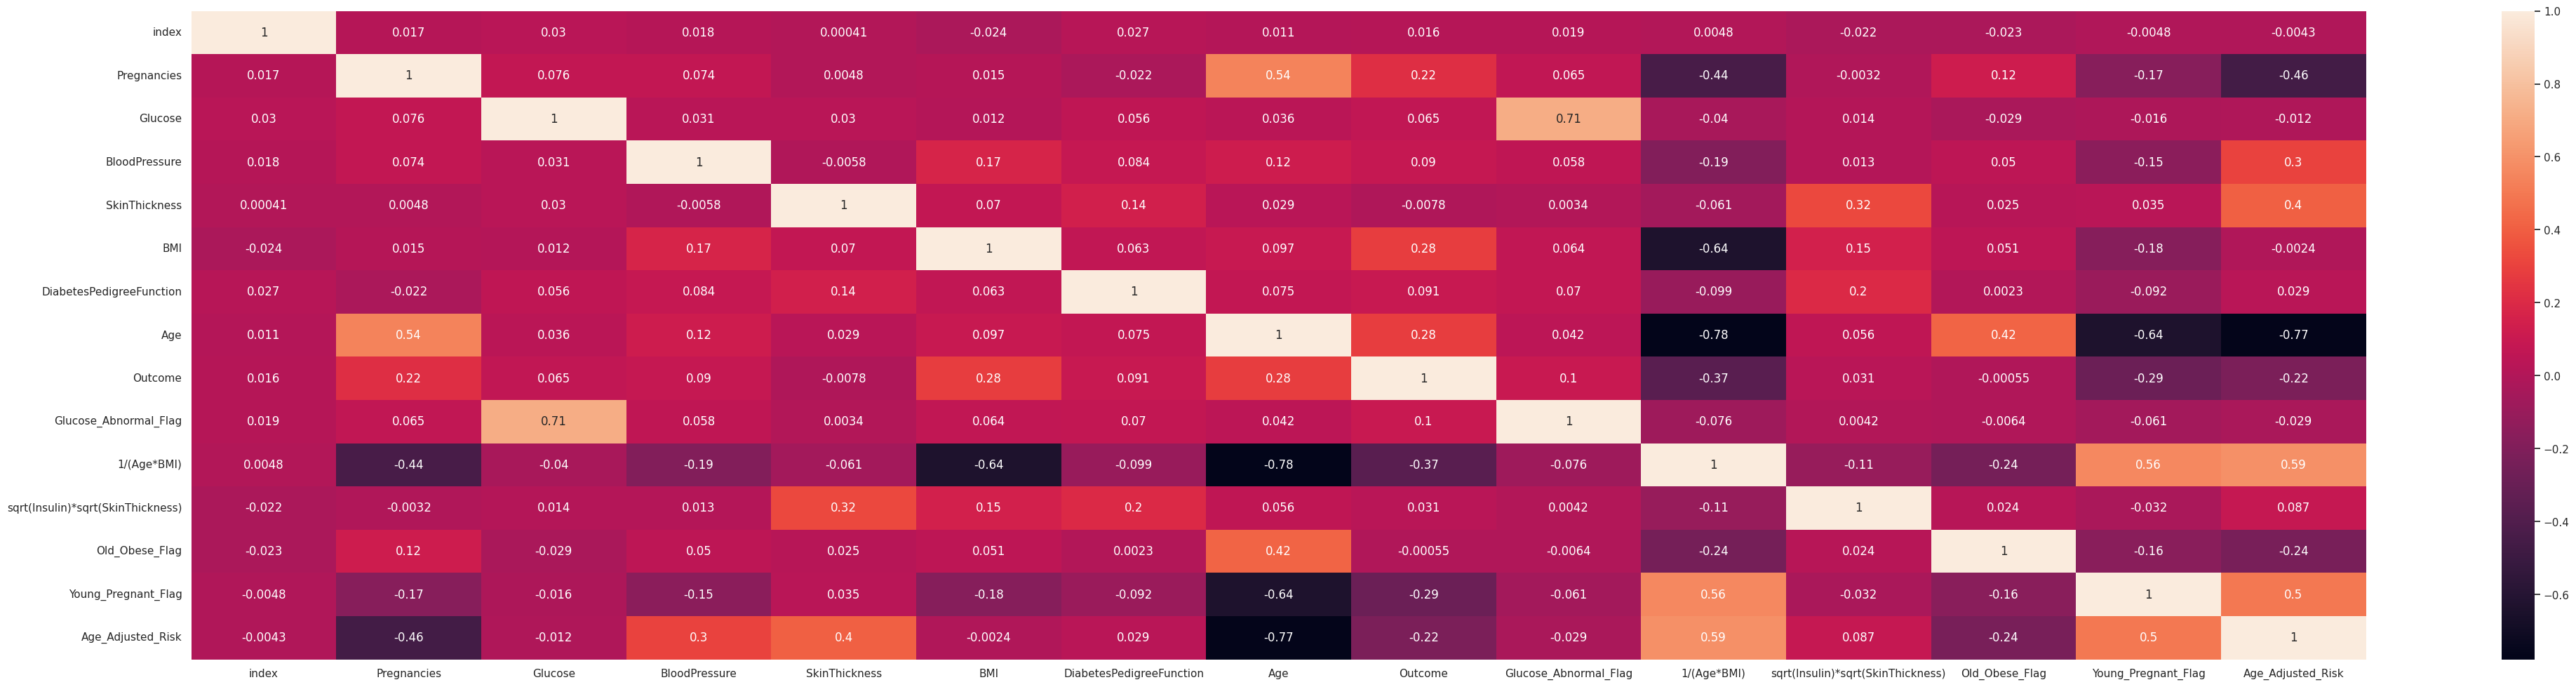

In [57]:

import lightgbm as lgb
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

train_data = pd.read_csv('../data/train_特徴量選択.csv')
test_data = pd.read_csv('../data/test_特徴量選択.csv')

train_data = train_data.drop("Unnamed: 0", axis=1)
test_data = test_data.drop("Unnamed: 0", axis=1)
# train_data = train_data.drop("Unnamed: 0.1", axis=1)
# test_data = test_data.drop("Unnamed: 0.1", axis=1)

# train_data = train_data.drop("Pregnancies.1", axis=1)
# test_data = test_data.drop("Pregnancies.1", axis=1)
# train_data = train_data.drop("Glucose.1", axis=1)
# test_data = test_data.drop("Glucose.1", axis=1)
# train_data = train_data.drop("BloodPressure.1", axis=1)
# test_data = test_data.drop("BloodPressure.1", axis=1)
# train_data = train_data.drop("SkinThickness.1", axis=1)
# test_data = test_data.drop("SkinThickness.1", axis=1)
# train_data = train_data.drop("BMI.1", axis=1)
# test_data = test_data.drop("BMI.1", axis=1)
# train_data = train_data.drop("DiabetesPedigreeFunction.1", axis=1)
# test_data = test_data.drop("DiabetesPedigreeFunction.1", axis=1)
# train_data = train_data.drop("Age.1", axis=1)
# test_data = test_data.drop("Age.1", axis=1)
# train_data = train_data.drop("1/(Age*BMI)", axis=1)
# test_data = test_data.drop("1/(Age*BMI)", axis=1)
# train_data = train_data.drop("sqrt(Insulin)*sqrt(SkinThickness)", axis=1)
# test_data = test_data.drop("sqrt(Insulin)*sqrt(SkinThickness)", axis=1)
train_data = train_data.drop("Age**5", axis=1)
test_data = test_data.drop("Age**5", axis=1)
train_data = train_data.drop("Insulin", axis=1)
test_data = test_data.drop("Insulin", axis=1)
train_data = train_data.drop("BMI**2/Glucose", axis=1)
test_data = test_data.drop("BMI**2/Glucose", axis=1)
train_data = train_data.drop("sqrt(Pregnancies)/Age", axis=1)
test_data = test_data.drop("sqrt(Pregnancies)/Age", axis=1)
train_data = train_data.drop("BMI**2*Glucose**3", axis=1)
test_data = test_data.drop("BMI**2*Glucose**3", axis=1)
train_data = train_data.drop("sqrt(DiabetesPedigreeFunction)/Glucose", axis=1)
test_data = test_data.drop("sqrt(DiabetesPedigreeFunction)/Glucose", axis=1)
train_data = train_data.drop("Age*Glucose**3", axis=1)
test_data = test_data.drop("Age*Glucose**3", axis=1)
train_data = train_data.drop("Insulin*log(DiabetesPedigreeFunction)", axis=1)
test_data = test_data.drop("Insulin*log(DiabetesPedigreeFunction)", axis=1)

datasets = [train_data, test_data]

# 1. 列間の演算による特徴量
for data in datasets:
  data['Old_Obese_Flag'] = ((data['Age'] > 50) & (data['BMI'] > 30)).astype(int)
  data['Young_Pregnant_Flag'] = ((data['Pregnancies'] > 0) & (data['Age'] < 30)).astype(int)
  data['Age_Adjusted_Risk'] = (0.6 * data['BloodPressure'] + 0.4 * data['SkinThickness']) / data['Age']



sns.set(style='darkgrid')
plt.figure(figsize=(50,12))
sns.heatmap(train_data.corr(), annot=True)

print(train_data.info())

# 特殊文字をアンダースコアに置換
train_data.columns = train_data.columns.str.replace(r'[{}\[\]":]', '_', regex=True)
test_data.columns = test_data.columns.str.replace(r'[{}\[\]":]', '_', regex=True)

# データ準備
X = train_data.drop(columns=['index', 'Outcome'])  # 説明変数
y = train_data['Outcome']  # 目的変数
print(X.head())

# 訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(train_data.shape[1] - 2)



In [58]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

# データ型の確認
print("データ型の確認（変換前）:")
print(X.dtypes)

# カテゴリ特徴量を数値に変換
categorical_features = [col for col in X.columns if X[col].dtype == 'object']
print(f"変換対象のカテゴリ特徴量: {categorical_features}")

le = LabelEncoder()
for col in categorical_features:
    X[col] = le.fit_transform(X[col])


# Optunaによるハイパーパラメータ最適化
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 20, 50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.7, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.7, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 20),
        'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 1.0),
        'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 1.0),
        'verbose': -1
    }

    k = 10
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        lgb_train = lgb.Dataset(X_train, y_train)
        lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

        gbm = lgb.train(
            params,
            lgb_train,
            num_boost_round=100,
            valid_sets=[lgb_val],
            callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
        )

        y_pred_proba = gbm.predict(X_val)
        auc = roc_auc_score(y_val, y_pred_proba)
        auc_scores.append(auc)

    return np.mean(auc_scores)

# Optunaで最適化を実行
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# 最適なパラメータの表示
print("最適なハイパーパラメータ:", study.best_params)
print("最適なAUC:", study.best_value)

# 以降のコード（モデル再訓練と評価）は同様にcategorical_featureを適用
best_params = study.best_params
best_params['objective'] = 'binary'
best_params['metric'] = 'auc'
best_params['verbose'] = -1

lgb_train = lgb.Dataset(X, y, categorical_feature=categorical_features)
gbm = lgb.train(
    best_params,
    lgb_train,
    num_boost_round=100,
    valid_sets=[lgb_train],
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)

# 交差検証で最終モデルの性能を確認
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)
accuracy_scores = []
auc_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\nFold {fold + 1}/{k}")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=categorical_features)
    lgb_val = lgb.Dataset(X_val, y_val, categorical_feature=categorical_features)
    gbm = lgb.train(
        best_params,
        lgb_train,
        num_boost_round=100,
        valid_sets=[lgb_val],
        callbacks=[lgb.early_stopping(stopping_rounds=10)]
    )
    y_pred_proba = gbm.predict(X_val)
    y_pred = [1 if x > 0.5 else 0 for x in y_pred_proba]

    accuracy = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    accuracy_scores.append(accuracy)
    auc_scores.append(auc)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print(f"Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

# 結果の表示
print("\n最適モデルによる評価:")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average AUC: {np.mean(auc_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1 Score: {np.mean(f1_scores):.4f}")

# 特徴量の重要度
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbm.feature_importance(importance_type='gain')
})
print("\n特徴量の重要度:")

print(feature_importance.sort_values(by='Importance', ascending=False))
feature_importance.sort_values(['Importance']).to_csv('../data/feature_importance.csv', header=False, index=False)

[I 2025-03-20 14:28:28,012] A new study created in memory with name: no-name-bb4e45a9-df12-41c3-a965-9e0d140aa7a7


データ型の確認（変換前）:
Pregnancies                            int64
Glucose                                int64
BloodPressure                          int64
SkinThickness                          int64
BMI                                  float64
DiabetesPedigreeFunction             float64
Age                                    int64
Glucose_Abnormal_Flag                  int64
1/(Age*BMI)                          float64
sqrt(Insulin)*sqrt(SkinThickness)    float64
Old_Obese_Flag                         int64
Young_Pregnant_Flag                    int64
Age_Adjusted_Risk                    float64
dtype: object
変換対象のカテゴリ特徴量: []


[I 2025-03-20 14:28:28,645] Trial 0 finished with value: 0.8154094635040146 and parameters: {'num_leaves': 26, 'learning_rate': 0.09491573668279908, 'feature_fraction': 0.9579455054272856, 'bagging_fraction': 0.9430139955284904, 'bagging_freq': 7, 'min_child_samples': 12, 'lambda_l1': 0.40333211147178194, 'lambda_l2': 0.37741597171674335}. Best is trial 0 with value: 0.8154094635040146.
[I 2025-03-20 14:28:29,645] Trial 1 finished with value: 0.803220986267713 and parameters: {'num_leaves': 37, 'learning_rate': 0.017221790388519263, 'feature_fraction': 0.9597271667192295, 'bagging_fraction': 0.8678866814743189, 'bagging_freq': 1, 'min_child_samples': 5, 'lambda_l1': 0.9733037574561577, 'lambda_l2': 0.0680520305270037}. Best is trial 0 with value: 0.8154094635040146.
[I 2025-03-20 14:28:30,208] Trial 2 finished with value: 0.7942679374058491 and parameters: {'num_leaves': 39, 'learning_rate': 0.010947409381413373, 'feature_fraction': 0.7553063672271728, 'bagging_fraction': 0.84895161698

最適なハイパーパラメータ: {'num_leaves': 25, 'learning_rate': 0.08024821706498117, 'feature_fraction': 0.8495533135560135, 'bagging_fraction': 0.9385056976536466, 'bagging_freq': 1, 'min_child_samples': 11, 'lambda_l1': 0.9117864767948196, 'lambda_l2': 0.5028227722868877}
最適なAUC: 0.826190443294793

Fold 1/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[72]	valid_0's auc: 0.881824
Accuracy: 0.7944, AUC: 0.8818

Fold 2/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[61]	valid_0's auc: 0.846809
Accuracy: 0.8531, AUC: 0.8468

Fold 3/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[82]	valid_0's auc: 0.869369
Accuracy: 0.8497, AUC: 0.8694

Fold 4/10
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[62]	valid_0's auc: 0.803219
Accuracy: 0.7587, AUC: 0.8032

Fold 5/10
Training until validation scores don't

In [59]:
# データ準備
X_test = test_data.drop(columns=['index'])  # 説明変数

# 予測
y_pred_proba = gbm.predict(X_test)  # 確率値
y_pred = [1 if x > 0.5 else 0 for x in y_pred_proba]  # 閾値0.5でクラス予測

# 結果の表示
print("Predicted Probabilities (first 10 samples):", y_pred_proba[:10])
print("Predicted Classes (first 10 samples):", y_pred[:10])


# 出力用データフレームを作成
output = pd.DataFrame({
    'index': test_data['index'],
    'Outcome': y_pred
})

# CSVファイルに保存
output.to_csv('../data/prediction.csv', header=False, index=False)
print("予測結果を 'prediction.csv' に出力しました。")

Predicted Probabilities (first 10 samples): [0.33095686 0.13808964 0.09289889 0.33824656 0.13457507 0.16142355
 0.34912306 0.08947667 0.40593218 0.13438491]
Predicted Classes (first 10 samples): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
予測結果を 'prediction.csv' に出力しました。


In [ ]:
# train_data = train_data.drop("High_Glucose_Flag", axis=1)
# test_data = test_data.drop("High_Glucose_Flag", axis=1)
# train_data = train_data.drop("Young_Pregnant_Flag", axis=1)
# test_data = test_data.drop("Young_Pregnant_Flag", axis=1)
# train_data = train_data.drop("Low_Value_Risk_Flag", axis=1)
# test_data = test_data.drop("Low_Value_Risk_Flag", axis=1)
# train_data = train_data.drop("Old_Obese_Flag", axis=1)
# test_data = test_data.drop("Old_Obese_Flag", axis=1)
# train_data = train_data.drop("Extreme_SkinThickness_Flag", axis=1)
# test_data = test_data.drop("Extreme_SkinThickness_Flag", axis=1)
# train_data = train_data.drop("Hypertension_Flag", axis=1)
# test_data = test_data.drop("Hypertension_Flag", axis=1)
# train_data = train_data.drop("Sqrt_Glucose", axis=1)
# test_data = test_data.drop("Sqrt_Glucose", axis=1)
# train_data = train_data.drop("Obesity_Flag", axis=1)
# test_data = test_data.drop("Obesity_Flag", axis=1)
# train_data = train_data.drop("Very_Old_Flag", axis=1)
# test_data = test_data.drop("Very_Old_Flag", axis=1)
# train_data = train_data.drop("Low_Risk_Composite_Flag", axis=1)
# test_data = test_data.drop("Low_Risk_Composite_Flag", axis=1)
# train_data = train_data.drop("High_SkinThickness_Flag", axis=1)
# test_data = test_data.drop("High_SkinThickness_Flag", axis=1)
# train_data = train_data.drop("BMI_Trim_Mean_Diff", axis=1)
# test_data = test_data.drop("BMI_Trim_Mean_Diff", axis=1)
# train_data = train_data.drop("Age_Category_Glucose_Mean", axis=1)
# test_data = test_data.drop("Age_Category_Glucose_Mean", axis=1)
# train_data = train_data.drop("Glucose_Cubed", axis=1)
# test_data = test_data.drop("Glucose_Cubed", axis=1)
# train_data = train_data.drop("Simple_Diabetes_Risk_Score", axis=1)
# test_data = test_data.drop("Simple_Diabetes_Risk_Score", axis=1)
# train_data = train_data.drop("Glucose_Abnormal_Flag", axis=1)
# test_data = test_data.drop("Glucose_Abnormal_Flag", axis=1)
# train_data = train_data.drop("Age_Category", axis=1)
# test_data = test_data.drop("Age_Category", axis=1)
# train_data = train_data.drop("BMI_Category", axis=1)
# test_data = test_data.drop("BMI_Category", axis=1)
# train_data = train_data.drop("BMI_Percentile_Rank", axis=1)
# test_data = test_data.drop("BMI_Percentile_Rank", axis=1)
# train_data = train_data.drop("BMI_BP_Weighted_Product", axis=1)
# test_data = test_data.drop("BMI_BP_Weighted_Product", axis=1)
# train_data = train_data.drop("BMI_Squared", axis=1)
# test_data = test_data.drop("BMI_Squared", axis=1)
# train_data = train_data.drop("High_Glucose_90th_Flag", axis=1)
# test_data = test_data.drop("High_Glucose_90th_Flag", axis=1)
# train_data = train_data.drop("Exp_Glucose", axis=1)
# test_data = test_data.drop("Exp_Glucose", axis=1)
# train_data = train_data.drop("Pregnancies", axis=1)
# test_data = test_data.drop("Pregnancies", axis=1)
# train_data = train_data.drop("Log_Glucose", axis=1)
# test_data = test_data.drop("Log_Glucose", axis=1)
# train_data = train_data.drop("Glucose_Z_Score", axis=1)
# test_data = test_data.drop("Glucose_Z_Score", axis=1)
# train_data = train_data.drop("Sin_Glucose", axis=1)
# test_data = test_data.drop("Sin_Glucose", axis=1)
# train_data = train_data.drop("Glucose_Level", axis=1)
# test_data = test_data.drop("Glucose_Level", axis=1)
# train_data = train_data.drop("Glucose_Median_Deviation", axis=1)
# test_data = test_data.drop("Glucose_Median_Deviation", axis=1)
# train_data = train_data.drop("Risk_Factor_Count", axis=1)
# test_data = test_data.drop("Risk_Factor_Count", axis=1)